In [21]:
import wave 
import pyroomacoustics as pa
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sp
import scipy

from calc_steering_vector import calculate_steering_vector

In [22]:
def write_file_from_time_signal(data, save_path, sample_rate):
    data = data.astype(np.int16)
    save_file = wave.open(save_path, 'w')
    save_file.setnchannels(1)
    save_file.setsampwidth(2)
    save_file.setframerate(sample_rate)
    save_file.writeframes(data)
    save_file.close()

In [23]:
def save_spectrogram_img(data, save_path, sample_rate, fft_size, noverlap):
    # スペクトログラムをプロットする
    fig = plt.figure(figsize=(10, 4))
    # スペクトログラムを表示する
    spectrum, freqs, t, im = plt.specgram(data, NFFT=fft_size, noverlap=noverlap, Fs=sample_rate)
    # カラーバーを表示する
    fig.colorbar(im).set_label('Intensity [dB]')
    # x軸のラベル
    plt.xlabel("Time [sec]")
    # y軸のラベル
    plt.ylabel("Frequency [Hz]")
    # 音声ファイルを画像として保存
    plt.savefig(save_path)

In [24]:
# 過去のマイクロホン入力信号の算出
def make_x_bar(x, D, Lh):
    """
    x: 入力信号 (M, Nk, Lt)
    D: 遅延フレーム数
    Lh: 残響除去フィルタのタップ長
    x_bar: 過去のマイクロホン入力信号 (Lh, M, Nk, Lt)
    """
    # フレーム数を取得
    Lt = np.shape(x)[2]

    print("x:", x.shape)
    """x: (num_microphones=2, freq_bins=513, time_frames=276)"""

    # 過去のマイクロホン入力信号の配列を準備
    x_bar = np.zeros(shape=(Lh,) + np.shape(x), dtype=np.complex)
    """x_bar: (tap_length, num_microphones=2, freq_bins=513, time_frames=276)"""

    for tau in range(Lh):
        print("x[:, :, :-(tau+D)]:", x[:, :, :-(tau+D)].shape)
        print("x_bar[tau, :, :, tau+D:]:", x_bar[tau, :, :, tau+D:].shape)
        x_bar[tau, :, :, tau+D:] = x[:, :, :-(tau+D)]
    """x_bar: (tap_length, num_microphones, freq_bins, time_frames)"""
    return x_bar

In [25]:
# WPEによる残響除去のソースコード
def dereverberation_wpe_multi(complex_spec, complex_spec_past, wpe_iterations=10):
    """
    complex_spec: マイクロホン入力信号 (num_microphones, freq_bins, time_frames)
    complex_spec_past: 過去のマイクロホン入力信号 (num_taps, num_microphones, freq_bins, time_frames)
    complex_spec_dereverb: 残響除去後の信号 (freq_bins, time_frames) 
    """
    # マイクロホン数・周波数・フレーム数・タップ長を取得する
    M = np.shape(complex_spec)[0]
    Nk = np.shape(complex_spec)[1]
    Lt = np.shape(complex_spec)[2]
    Lh = np.shape(complex_spec_past)[0]

    # 入力信号の形式を変更・変数を初期化
    x_bar = np.reshape(complex_spec_past, [Lh*M, Nk, Lt])
    """x_bar: (num_taps*num_microphones, freq_bins, time_frames)"""
    # var = np.square(np.abs(complex_spec[0, :, :]))
    # """var: (freq_bins, time_frames)"""
    var = np.square(np.abs(complex_spec))
    """var: (num_microphones, freq_bins, time_frames)"""

    cost_buff = []
    for t in range(wpe_iterations):
        # 共分散行列を計算
        x_bar_x_bar_h = np.einsum('mkt,ikt,jkt->mkij', 1/var, x_bar, np.conjugate(x_bar))
        """x_bar_x_bar_h: (freq_bins, num_taps*num_microphones, num_taps*num_microphones)"""
        # 相関ベクトルを計算
        correlation = np.einsum('mkt,ikt,kt->mki', 1/var, x_bar, np.conjugate(complex_spec[0, :, :]))
        """x_bar_x_bar_h: (freq_bins, num_taps*num_microphones)"""
        # 残響除去フィルタを算出
        # dereverb_filter = np.linalg.solve(x_bar_x_bar_h, correlation)
        # """dereverb_filter: (freq_bins, num_taps*num_microphones)"""
        dereverb_filter = np.linalg.solve(x_bar_x_bar_h, correlation)
        """dereverb_filter: (freq_bins, num_taps*num_microphones, num_microphones) or (num_microphones, freq_bins, num_taps*num_microphones)"""
        # 残響除去実施
        # complex_spec_reverb = np.einsum('kj,jkt->kt', np.conjugate(dereverb_filter), x_bar)
        # """complex_spec_reverb: (freq_bins, time_frames)"""
        complex_spec_reverb = np.einsum('mkj,jkt->mkt', np.conjugate(dereverb_filter), x_bar)
        """complex_spec_reverb: (num_microphones, freq_bins, time_frames)"""
        # complex_spec_dereverb = complex_spec[0, :, :] - complex_spec_reverb
        # """complex_spec_dereverb: (freq_bins, time_frames)"""
        complex_spec_dereverb = complex_spec - complex_spec_reverb
        """complex_spec_dereverb: (num_microphones, freq_bins, time_frames)"""
        # パラメータ更新
        var = np.square(np.abs(complex_spec_dereverb))
        var = np.maximum(var, 1.e-8) # 0除算を避けるため
        # コスト計算
        cost = np.mean(np.log(var))
        cost_buff.append(cost)

    return complex_spec_dereverb, cost_buff

In [29]:
# WPEによるマルチチャンネル音声の残響除去
def dereverberation_wpe_multi(complex_spec, complex_spec_past, wpe_iterations=10):
    """
    complex_spec: マイクロホン入力信号 (num_microphones, freq_bins, time_frames)
    complex_spec_past: 過去のマイクロホン入力信号 (num_taps, num_microphones, freq_bins, time_frames)
    complex_spec_dereverb: 残響除去後の信号 (freq_bins, time_frames) 
    """
    # マイクロホン数・周波数・フレーム数・タップ長を取得する
    M = np.shape(complex_spec)[0]
    Nk = np.shape(complex_spec)[1]
    Lt = np.shape(complex_spec)[2]
    Lh = np.shape(complex_spec_past)[0]

    # 入力信号の形式を変更・変数を初期化
    x_bar = np.reshape(complex_spec_past, [Lh*M, Nk, Lt])
    """x_bar: (num_taps*num_microphones, freq_bins, time_frames)"""
    var = np.square(np.abs(complex_spec)) # 各時間周波数における音声の分散
    """var: (num_microphones, freq_bins, time_frames)"""

    cost_buff = []
    for t in range(wpe_iterations):
        # 共分散行列を計算
        x_bar_x_bar_h = np.einsum('mkt,ikt,jkt->mkij', 1/var, x_bar, np.conjugate(x_bar))
        """x_bar_x_bar_h: (num_microphones, freq_bins, num_taps*num_microphones, num_taps*num_microphones)"""
        # 相関ベクトルを計算
        # correlation = np.einsum('mkt,ikt,kt->mki', 1/var, x_bar, np.conjugate(complex_spec[0, :, :])) # TODO 一つ目のマイクロホンと相関をとっている部分が怪しい
        correlation = np.einsum('mkt,ikt,mkt->mki', 1/var, x_bar, np.conjugate(complex_spec))
        """correlation: (num_microphones, freq_bins, num_taps*num_microphones)"""
        # 残響除去フィルタを算出
        dereverb_filter = np.linalg.solve(x_bar_x_bar_h, correlation)
        """dereverb_filter: (num_microphones, freq_bins, num_taps*num_microphones)"""
        # 残響除去実施
        complex_spec_reverb = np.einsum('mkj,jkt->mkt', np.conjugate(dereverb_filter), x_bar)
        """complex_spec_reverb: (num_microphones, freq_bins, time_frames)"""
        complex_spec_dereverb = complex_spec - complex_spec_reverb
        """complex_spec_dereverb: (num_microphones, freq_bins, time_frames)"""
        # パラメータ更新
        var = np.square(np.abs(complex_spec_dereverb))
        var = np.maximum(var, 1.e-8) # 0除算を避けるため
        # コスト計算
        cost = np.mean(np.log(var))
        cost_buff.append(cost)

    return complex_spec_dereverb, cost_buff

In [30]:
# WPEによる残響除去のソースコード
def dereverberation_wpe(x, x_bar, wpe_iterations=10):
    """
    x: 入力信号 (M, Nk, Lt)
    x_bar: 過去のマイクロホン入力信号 (Lh, M, Nk, Lt)
    x_dereverb: 残響除去後の信号 (Nk, Lt) 
    """
    # マイクロホン数・周波数・フレーム数・タップ長を取得する
    M = np.shape(x)[0]
    Nk = np.shape(x)[1]
    Lt = np.shape(x)[2]
    Lh = np.shape(x_bar)[0]

    # 入力信号の形式を変更・変数を初期化
    x_bar = np.reshape(x_bar, [Lh*M, Nk, Lt])
    v = np.square(np.abs(x[0, :, :]))
    """v: (freq_bins, time_frames)"""

    cost_buff = []
    for t in range(wpe_iterations):
        # 共分散行列を計算
        x_bar_x_bar_h = np.einsum('kt,ikt,jkt->kij', 1/v, x_bar, np.conjugate(x_bar))
        # 相関ベクトルを計算
        correlation = np.einsum('kt,ikt,kt->ki', 1/v, x_bar, np.conjugate(x[0, :, :]))
        # フィルタ算出
        filter = np.linalg.solve(x_bar_x_bar_h, correlation)
        """filter: (freq_bins, num_taps*num_microphones)"""
        # 残響除去実施
        x_reverb = np.einsum('kj,jkt->kt', np.conjugate(filter), x_bar)
        """x_reverb: (freq_bins, time_frames)"""
        x_dereverb = x[0, :, :] - x_reverb
        # パラメータ更新
        v = np.square(np.abs(x_dereverb))
        v = np.maximum(v, 1.e-8) # 0除算を避けるため
        # コスト計算
        cost = np.mean(np.log(v))
        cost_buff.append(cost)

    return x_dereverb, cost_buff

x: (2, 513, 276)
x[:, :, :-(tau+D)]: (2, 513, 273)
x_bar[tau, :, :, tau+D:]: (2, 513, 273)
x[:, :, :-(tau+D)]: (2, 513, 272)
x_bar[tau, :, :, tau+D:]: (2, 513, 272)
x[:, :, :-(tau+D)]: (2, 513, 271)
x_bar[tau, :, :, tau+D:]: (2, 513, 271)
x[:, :, :-(tau+D)]: (2, 513, 270)
x_bar[tau, :, :, tau+D:]: (2, 513, 270)
x[:, :, :-(tau+D)]: (2, 513, 269)
x_bar[tau, :, :, tau+D:]: (2, 513, 269)
x[:, :, :-(tau+D)]: (2, 513, 268)
x_bar[tau, :, :, tau+D:]: (2, 513, 268)
x[:, :, :-(tau+D)]: (2, 513, 267)
x_bar[tau, :, :, tau+D:]: (2, 513, 267)
x[:, :, :-(tau+D)]: (2, 513, 266)
x_bar[tau, :, :, tau+D:]: (2, 513, 266)
x[:, :, :-(tau+D)]: (2, 513, 265)
x_bar[tau, :, :, tau+D:]: (2, 513, 265)
x[:, :, :-(tau+D)]: (2, 513, 264)
x_bar[tau, :, :, tau+D:]: (2, 513, 264)


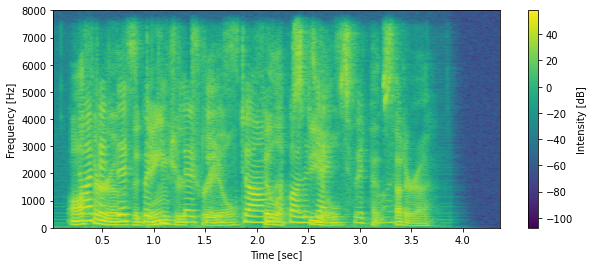

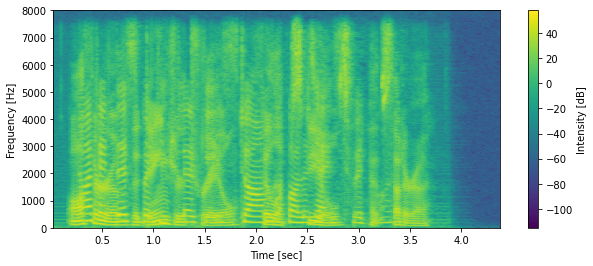

In [31]:
if __name__ == "__main__":
    # 乱数の種を初期化
    np.random.seed(0)
    # 畳み込みに用いる波形
    clean_wave_files = ["../audio_separation/Beamformer/CMU_ARCTIC/cmu_us_aew/wav/arctic_a0001.wav", "../audio_separation/Beamformer/CMU_ARCTIC/cmu_us_axb/wav/arctic_a0002.wav"]
    # 雑音だけの区間のフレーム数
    n_noise_only = 40000
    # 音源数
    n_sources = len(clean_wave_files)
    # 音声波形の長さを調べる
    n_samples = 0
    # ファイルを読み込む
    for clean_wave_file in clean_wave_files:
        wav = wave.open(clean_wave_file)
        if n_samples<wav.getnframes():
            n_samples=wav.getnframes()
        wav.close()
    clean_data = np.zeros([n_sources, n_samples])

    # ファイルを読み込む
    s = 0
    for clean_wave_file in clean_wave_files:
        wav = wave.open(clean_wave_file)
        data = wav.readframes(wav.getnframes())
        data = np.frombuffer(data, dtype=np.int16)
        data = data/np.iinfo(np.int16).max
        clean_data[s, :wav.getnframes()] = data
        wav.close()
        s = s+1

    # シミュレーションのパラメータ
    n_sim_sources = 2
    # サンプリングレート [Hz]
    sample_rate = 16000
    # フレームサイズ
    N = 1024
    # フレームシフト
    Nshift = int(N/4)
    # 周波数の数
    Nk = N / 2 + 1
    # 各ビンの周波数
    freqs = np.arange(0, Nk, 1) * sample_rate / N
    # 生成した音が割れないようにするための振幅調整用パラメータ
    amp_decay = 20 
    # 音声と雑音の比率 [dB]
    SNR = 90.
    # 部屋の大きさ
    room_dim = np.r_[10.0, 10.0, 10.0]
    # マイクロホンアレイを置く部屋の場所
    mic_array_loc = room_dim / 2 + np.random.randn(3) * 0.1
    # マイクロホンアレイのマイクロホン配置
    mic_alignments = np.array(
            [[x, 0.0, 0.0] for x in np.arange(-0.01, 0.02, 0.02)]
    )
    # マイクロホン数
    n_channels = np.shape(mic_alignments)[0]
    # get the microphone array
    R  = mic_alignments.T + mic_array_loc[:, None]
    """R: (3D-coordinate(x,y,z)=3, num_microphones)"""
    # 部屋を生成する
    room = pa.ShoeBox(room_dim, fs=sample_rate, max_order=17, absorption=0.4)
    # room_no_noise = pa.ShoeBox(room_dim, fs=sample_rate, max_order=17, absorption=0.4)
    # 用いるマイクロホンアレイの情報を設置する
    room.add_microphone_array(pa.MicrophoneArray(R, fs=room.fs))
    # room_no_noise.add_microphone_array(pa.MicrophoneArray(R, fs=room.fs))
    # 音源の場所
    doas  = np.array(
        [[np.pi/2, 0],
        [np.pi/2, np.pi]]
        )
    # 音源とマイクロホンの距離
    distance = 1.
    source_locations = np.zeros((3, doas.shape[0]), dtype=doas.dtype)
    """source_locations: (xyz, num_sources)"""
    source_locations[0,  :] = np.cos(doas[:, 1]) * np.sin(doas[:, 0]) 
    source_locations[1,  :] = np.sin(doas[:, 1]) * np.sin(doas[:, 0])
    source_locations[2,  :] = np.cos(doas[:, 0])
    source_locations *= distance
    source_locations += mic_array_loc[:, None] # マイクロホンアレイからの相対位置→絶対位置
    # print("clean_data:", np.shape(clean_data))

    # 各音源をシミュレーションに追加する
    for s in range(n_sim_sources):
        clean_data[s] /= np.std(clean_data[s])
        room.add_source(source_locations[:, s], signal=clean_data[s])
        # if s == 0:
        #     room_no_noise.add_source(source_locations[:, s], signal=clean_data[s])

    # シミュレーションを回す
    room.simulate(snr=SNR)
    # room_no_noise.simulate(snr=90)

    # 畳み込んだ波形を取得する
    multi_conv_data = room.mic_array.signals
    """multi_conv_data: (num_channels, num_samples)"""
    # multi_conv_data_no_noise = room_no_noise.mic_array.signals
    # """multi_conv_data_no_noise: (num_channels, num_samples)"""

    # Near仮定に基づくステアリングベクトルを計算: steering_vectors(Nk × Ns × M)
    near_steering_vectors = calculate_steering_vector(R, source_locations, freqs,  is_use_far=False)
    """near_steering_vectors: (freq_bins, num_sources, num_microphones)"""

    # 処理前の音声をファイルに書き込む
    write_file_from_time_signal(multi_conv_data[0]*np.iinfo(np.int16).max/amp_decay, "./wav/original.wav", sample_rate)
    save_spectrogram_path = "./spectrogram/original.png"
    save_spectrogram_img(multi_conv_data[0]*np.iinfo(np.int16).max/amp_decay, save_spectrogram_path, sample_rate, fft_size=N, noverlap=N-Nshift)

    # 短時間フーリエ変換
    f, t, stft_data = sp.stft(multi_conv_data, fs=sample_rate, window="hann", nperseg=N, noverlap=N-Nshift)
    """f: (freq_bins,), t: (1,), stft_data:(num_microphones, freq_bins, time_frames)"""

    # 過去のマイクロホン入力信号
    stft_data_past = make_x_bar(stft_data, D=3, Lh=10)

    # # 残響除去
    # x_dereverb_wpe, _ = dereverberation_wpe(stft_data, stft_data_past)
    
    # # 逆短時間フーリエ変換
    # t, dereverbed_wpe_out = sp.istft(x_dereverb_wpe, fs=sample_rate, window="hann", nperseg=N, noverlap=N-Nshift)

    # # 大きさを調整する
    # dereverbed_wpe_out = dereverbed_wpe_out * np.iinfo(np.int16).max / amp_decay

    # # ファイルに書き込む
    # write_file_from_time_signal(dereverbed_wpe_out, "./wav/dereverbed_wpe_out.wav", sample_rate)
    # save_spectrogram_path = "./spectrogram/dereverbed_wpe_out.png"
    # save_spectrogram_img(dereverbed_wpe_out, save_spectrogram_path, sample_rate, fft_size=N, noverlap=N-Nshift)

    # 残響除去
    x_dereverb_wpe, _ = dereverberation_wpe_multi(stft_data, stft_data_past)
    
    # 逆短時間フーリエ変換
    t, dereverbed_wpe_out = sp.istft(x_dereverb_wpe[0], fs=sample_rate, window="hann", nperseg=N, noverlap=N-Nshift)

    # 大きさを調整する
    dereverbed_wpe_out = dereverbed_wpe_out * np.iinfo(np.int16).max / amp_decay

    # ファイルに書き込む
    write_file_from_time_signal(dereverbed_wpe_out, "./wav/dereverbed_wpe_out.wav", sample_rate)
    save_spectrogram_path = "./spectrogram/dereverbed_wpe_out.png"
    save_spectrogram_img(dereverbed_wpe_out, save_spectrogram_path, sample_rate, fft_size=N, noverlap=N-Nshift)
